Comparison of empirical cIM and GNN method for conditional GM prediction at the aggregate level.  
All plots and visualizations are based on validation data.

In [1]:
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import ml_tools as mlt
import sim_ranking as sr
import spatial_hazard as sh

sns.set_theme(style="white")

In [2]:
gnn_results_dir = "/Users/claudy/dev/work/data/sim_ranking/results/gnn/1008_1447_cv_nzgmdb4p0_4_8_normIMs_5000epochs"

In [3]:
gnn_results_dir = Path(gnn_results_dir)
cim_results_dir = gnn_results_dir / "cim_results"
warnings.simplefilter(action='ignore', category=FutureWarning)

**Result Directory:** `{python} str(gnn_results_dir)`


In [4]:
# Load the combined validation results
gnn_val_results = pd.read_parquet(gnn_results_dir / "val_results.parquet").sort_index()
cim_val_results = pd.read_parquet(cim_results_dir / "val_results.parquet").sort_index()

# Load the validation results for each validation fold - GNN
gnn_cv_dirs = [cur_result for cur_result in gnn_results_dir.glob("cv_*") if cur_result.is_dir()]
gnn_cv_val_results = {cur_dir.stem: pd.read_parquet(cur_dir / "val_results.parquet") for cur_dir in gnn_cv_dirs}
gnn_cv_val_res_dfs = {cur_key: sr.ml.gnn_gm.get_residuals(cur_result) for cur_key, cur_result in gnn_cv_val_results.items()}
gnn_cv_train_results = {cur_dir.stem: pd.read_parquet(cur_dir / "train_results.parquet") for cur_dir in gnn_cv_dirs}

# Load the validation results for each validation fold - cIM
cim_cv_dirs = [cur_dir / "cim_results" for cur_dir in gnn_cv_dirs]
cim_cv_val_results = {cur_dir.stem: pd.read_parquet(cur_dir / "val_results.parquet") for cur_dir in cim_cv_dirs}
cim_cv_val_res_dfs = {cur_key: sr.ml.gnn_gm.get_residuals(cur_result, pred_suffix="cond_mean") for cur_key, cur_result in cim_cv_val_results.items()}

In [5]:
# Some sanity checking
assert gnn_val_results.shape[0] == cim_val_results.shape[0]
assert gnn_val_results.index.equals(cim_val_results.index)

In [6]:
# Compute residuals - GNN
gnn_val_res_df = sr.ml.gnn_gm.get_residuals(gnn_val_results)
assert gnn_val_res_df.index.equals(gnn_val_results.index)
gnn_val_res_df["cv_iter"] = gnn_val_results["cv_iter"]

gnn_val_res_mean_std_df = pd.concat((gnn_val_res_df[sr.constants.PSA_KEYS].mean(axis=0), gnn_val_res_df[sr.constants.PSA_KEYS].std(axis=0)), axis=1)
gnn_val_res_mean_std_df.columns = ["mean", "std"]

In [7]:
# Compute residuals - cIM
cim_val_res_df = sr.ml.gnn_gm.get_residuals(cim_val_results, pred_suffix="cond_mean")
assert cim_val_res_df.index.equals(cim_val_results.index)
cim_val_res_df["cv_iter"] = cim_val_results["cv_iter"]

cim_val_res_mean_std_df = pd.concat((cim_val_res_df[sr.constants.PSA_KEYS].mean(axis=0), cim_val_res_df[sr.constants.PSA_KEYS].std(axis=0)), axis=1)
cim_val_res_mean_std_df.columns = ["mean", "std"]

In [8]:
# Plot config
plot_ims = ["pSA_0.01", "pSA_0.1", "pSA_0.5", "pSA_1.0", "pSA_3.0", "pSA_10.0"]
n_plot_ims = len(plot_ims)

## CV Overview

In [9]:
gnn_cv_val_n_scenarios = pd.DataFrame({cur_key: [cur_cv_res.shape[0], cur_key, "val"] for cur_key, cur_cv_res in gnn_cv_val_results.items()}, index=["n_scenarios", "cv_iter", "type"]).T
gnn_cv_train_n_scenarios = pd.DataFrame({cur_key: [cur_cv_res.shape[0], cur_key, "train"] for cur_key, cur_cv_res in gnn_cv_train_results.items()}, index=["n_scenarios", "cv_iter", "type"]).T

In [10]:
n_scenarios_df = pd.concat((gnn_cv_val_n_scenarios, gnn_cv_train_n_scenarios), axis=0).sort_values("cv_iter").reset_index(drop=True)

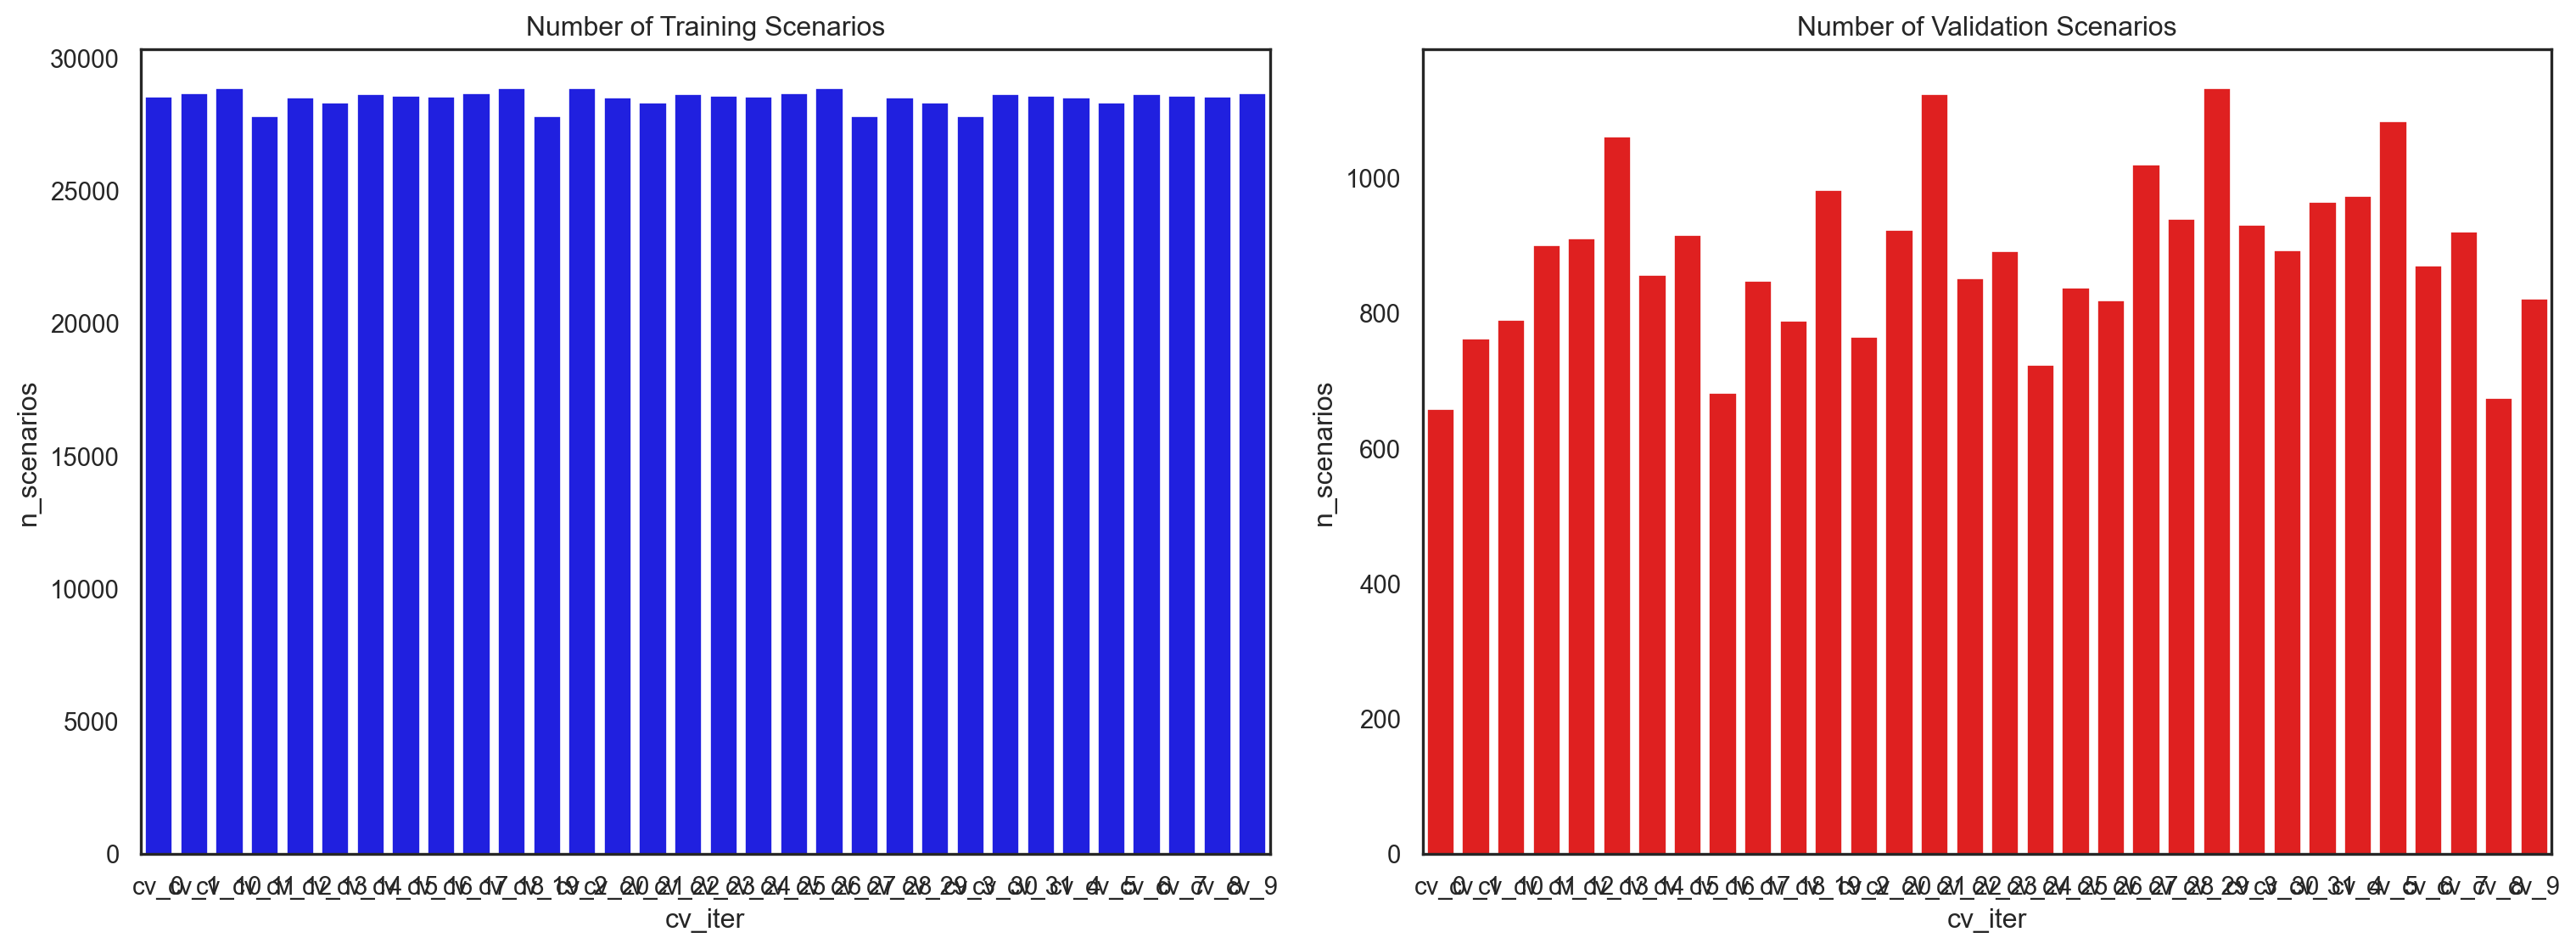

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=n_scenarios_df[n_scenarios_df["type"] == "train"], x="cv_iter", y="n_scenarios", color="blue", ax=ax1)
ax1.set_title("Number of Training Scenarios")

sns.barplot(data=n_scenarios_df[n_scenarios_df["type"] == "val"], x="cv_iter", y="n_scenarios", color="red", ax=ax2)
ax2.set_title("Number of Validation Scenarios")

fig.tight_layout()

## Residual Histograms

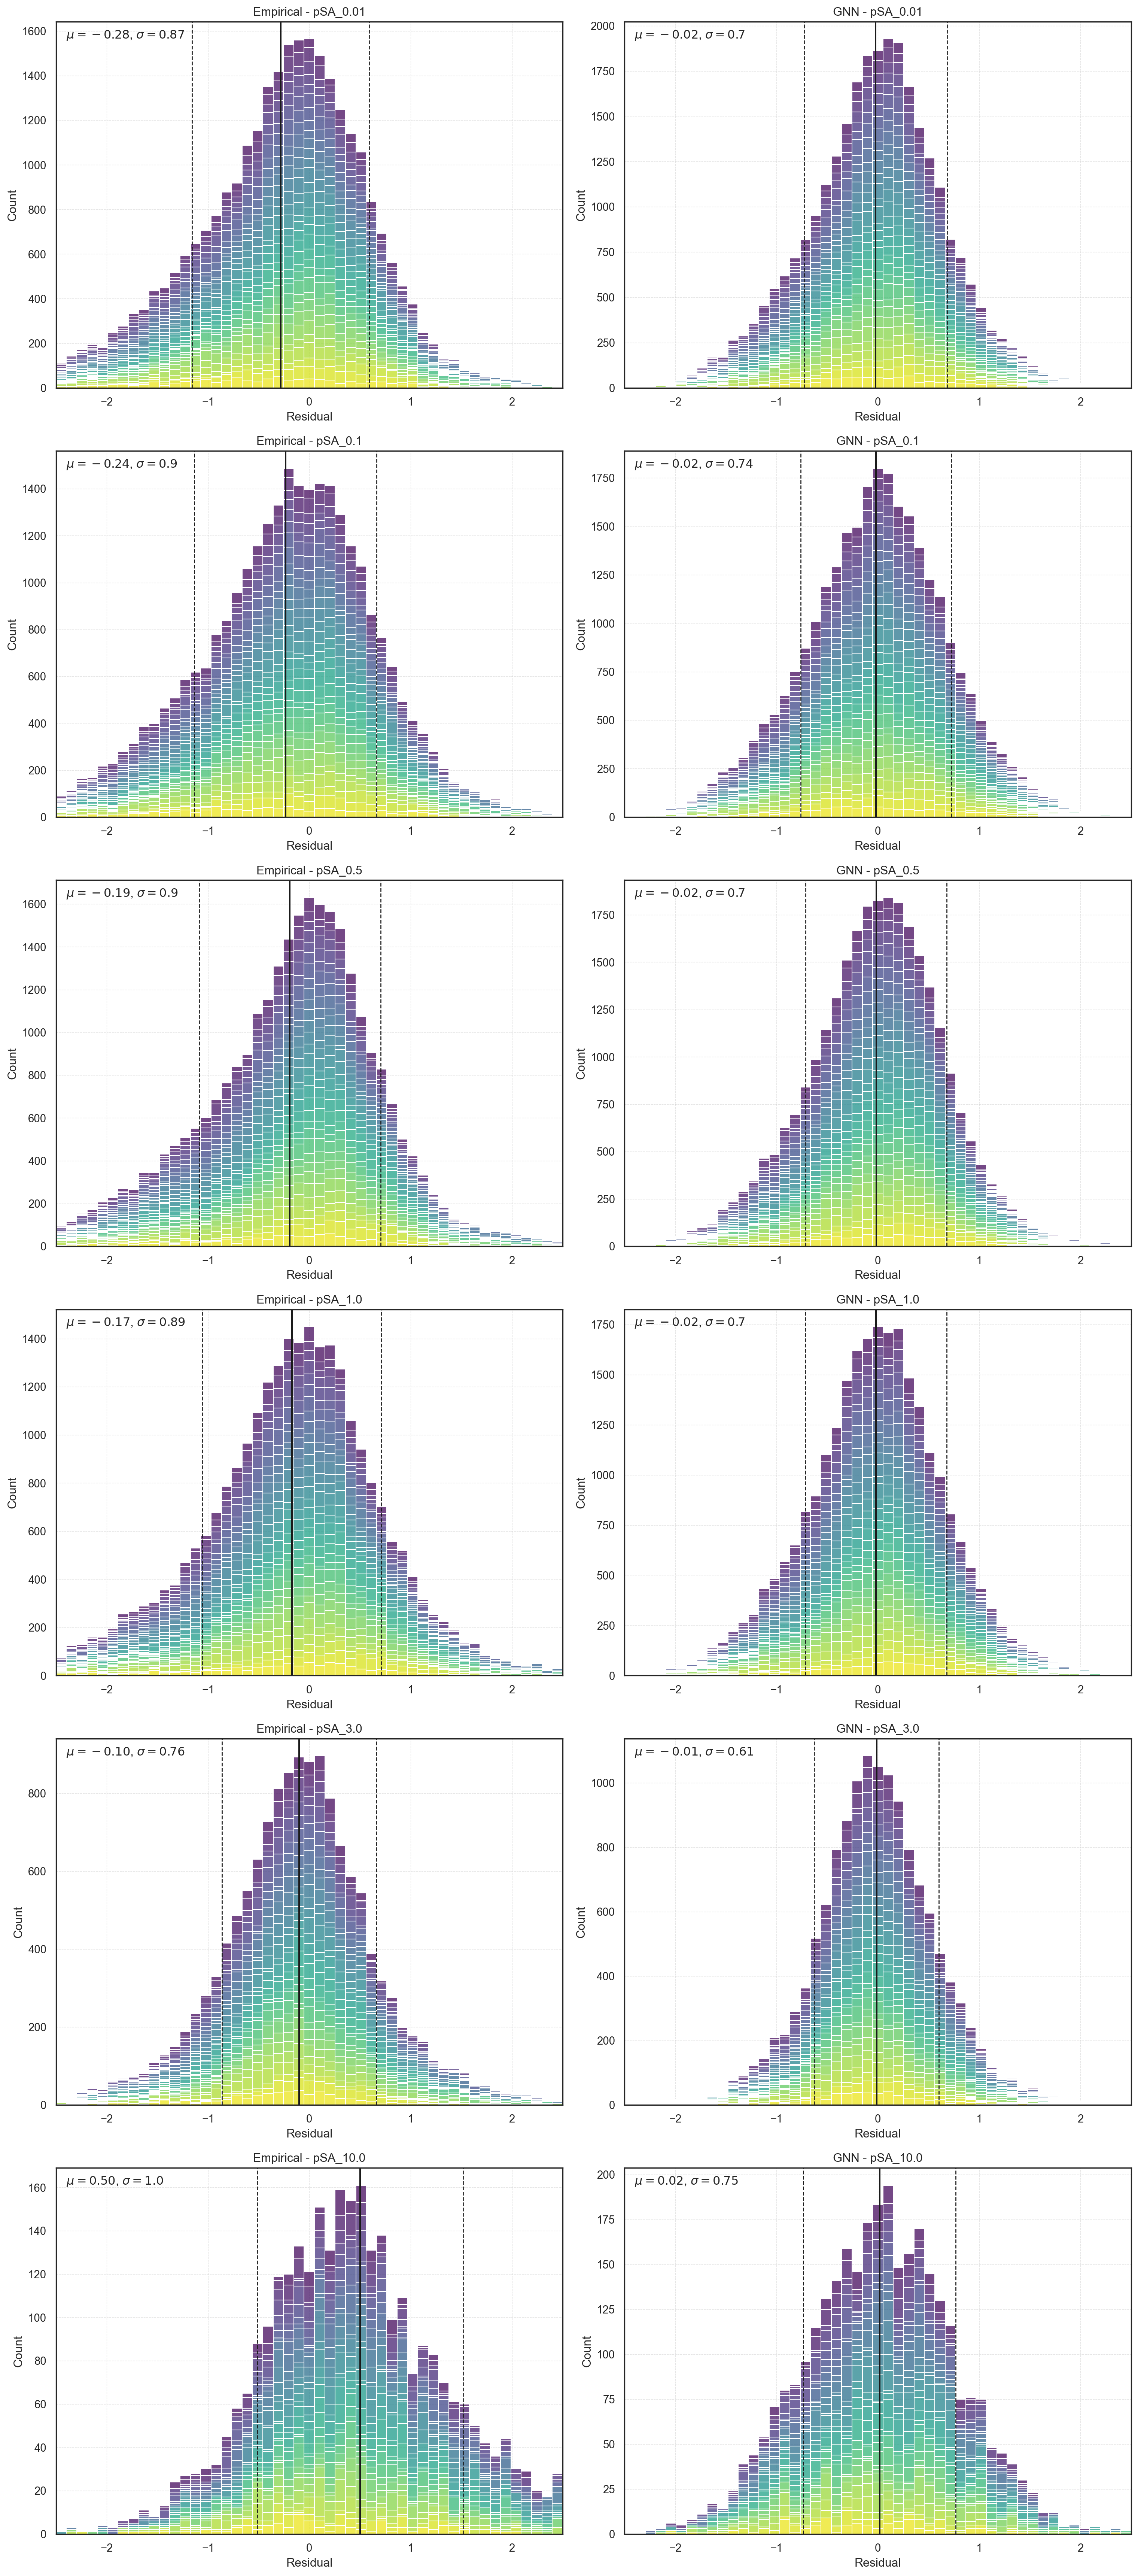

In [12]:
n_bins = 50
x_min, x_max = -2.5, 2.5
bins = np.linspace(x_min, x_max, n_bins)

fig, axs = mlt.plotting.get_fig_axes(2 * n_plot_ims, 2, -1, (8, 6))

for i, cur_im in enumerate(plot_ims):
    ax1, ax2 = axs[i * 2], axs[i * 2 + 1]
    
    # Empirical results
    cur_mean = cim_val_res_mean_std_df.loc[cur_im, "mean"]
    cur_std = cim_val_res_mean_std_df.loc[cur_im, "std"]
    ax1.axvline(cur_mean, color="k", linestyle="-", label="Mean", linewidth=1.5)
    ax1.axvline(cur_mean + cur_std, color="k", linestyle="--", label="Std", linewidth=1.0)
    ax1.axvline(cur_mean - cur_std, color="k", linestyle="--", linewidth=1.0)
    
    sns.histplot(cim_val_res_df, x=cur_im, bins=bins, ax=ax1, common_bins=True, hue="cv_iter", multiple="stack", legend=False, palette="viridis")
    
    # cur_ax.hist(val_res_df[cur_im], bins=bins, label="Train Data")
    ax1.set_xlabel(f"Residual")
    ax1.set_ylabel(f"Count")
    ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
    ax1.set_xlim(x_min, x_max )
    ax1.set_title(f"Empirical - {cur_im}")

    ax1.text(0.02, 0.98, f"$\mu = {cur_mean:.2f}$, $\sigma = {cur_std:.2}$", horizontalalignment="left",
                verticalalignment="top", transform=ax1.transAxes)
    
    # GNN results
    cur_mean = gnn_val_res_mean_std_df.loc[cur_im, "mean"]
    cur_std = gnn_val_res_mean_std_df.loc[cur_im, "std"]
    ax2.axvline(cur_mean, color="k", linestyle="-", label="Mean", linewidth=1.5)
    ax2.axvline(cur_mean + cur_std, color="k", linestyle="--", label="Std", linewidth=1.0)
    ax2.axvline(cur_mean - cur_std, color="k", linestyle="--", linewidth=1.0)
    
    sns.histplot(gnn_val_res_df, x=cur_im, bins=bins, ax=ax2, common_bins=True, hue="cv_iter", multiple="stack", legend=False, palette="viridis")
    
    # cur_ax.hist(val_res_df[cur_im], bins=bins, label="Train Data")
    ax2.set_xlabel(f"Residual")
    ax2.set_ylabel(f"Count")
    ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
    ax2.set_xlim(x_min, x_max )
    ax2.set_title(f"GNN - {cur_im}")

    ax2.text(0.02, 0.98, f"$\mu = {cur_mean:.2f}$, $\sigma = {cur_std:.2}$", horizontalalignment="left",
                verticalalignment="top", transform=ax2.transAxes)
    
fig.tight_layout()

### Bias & (Residual) Standard Deviation

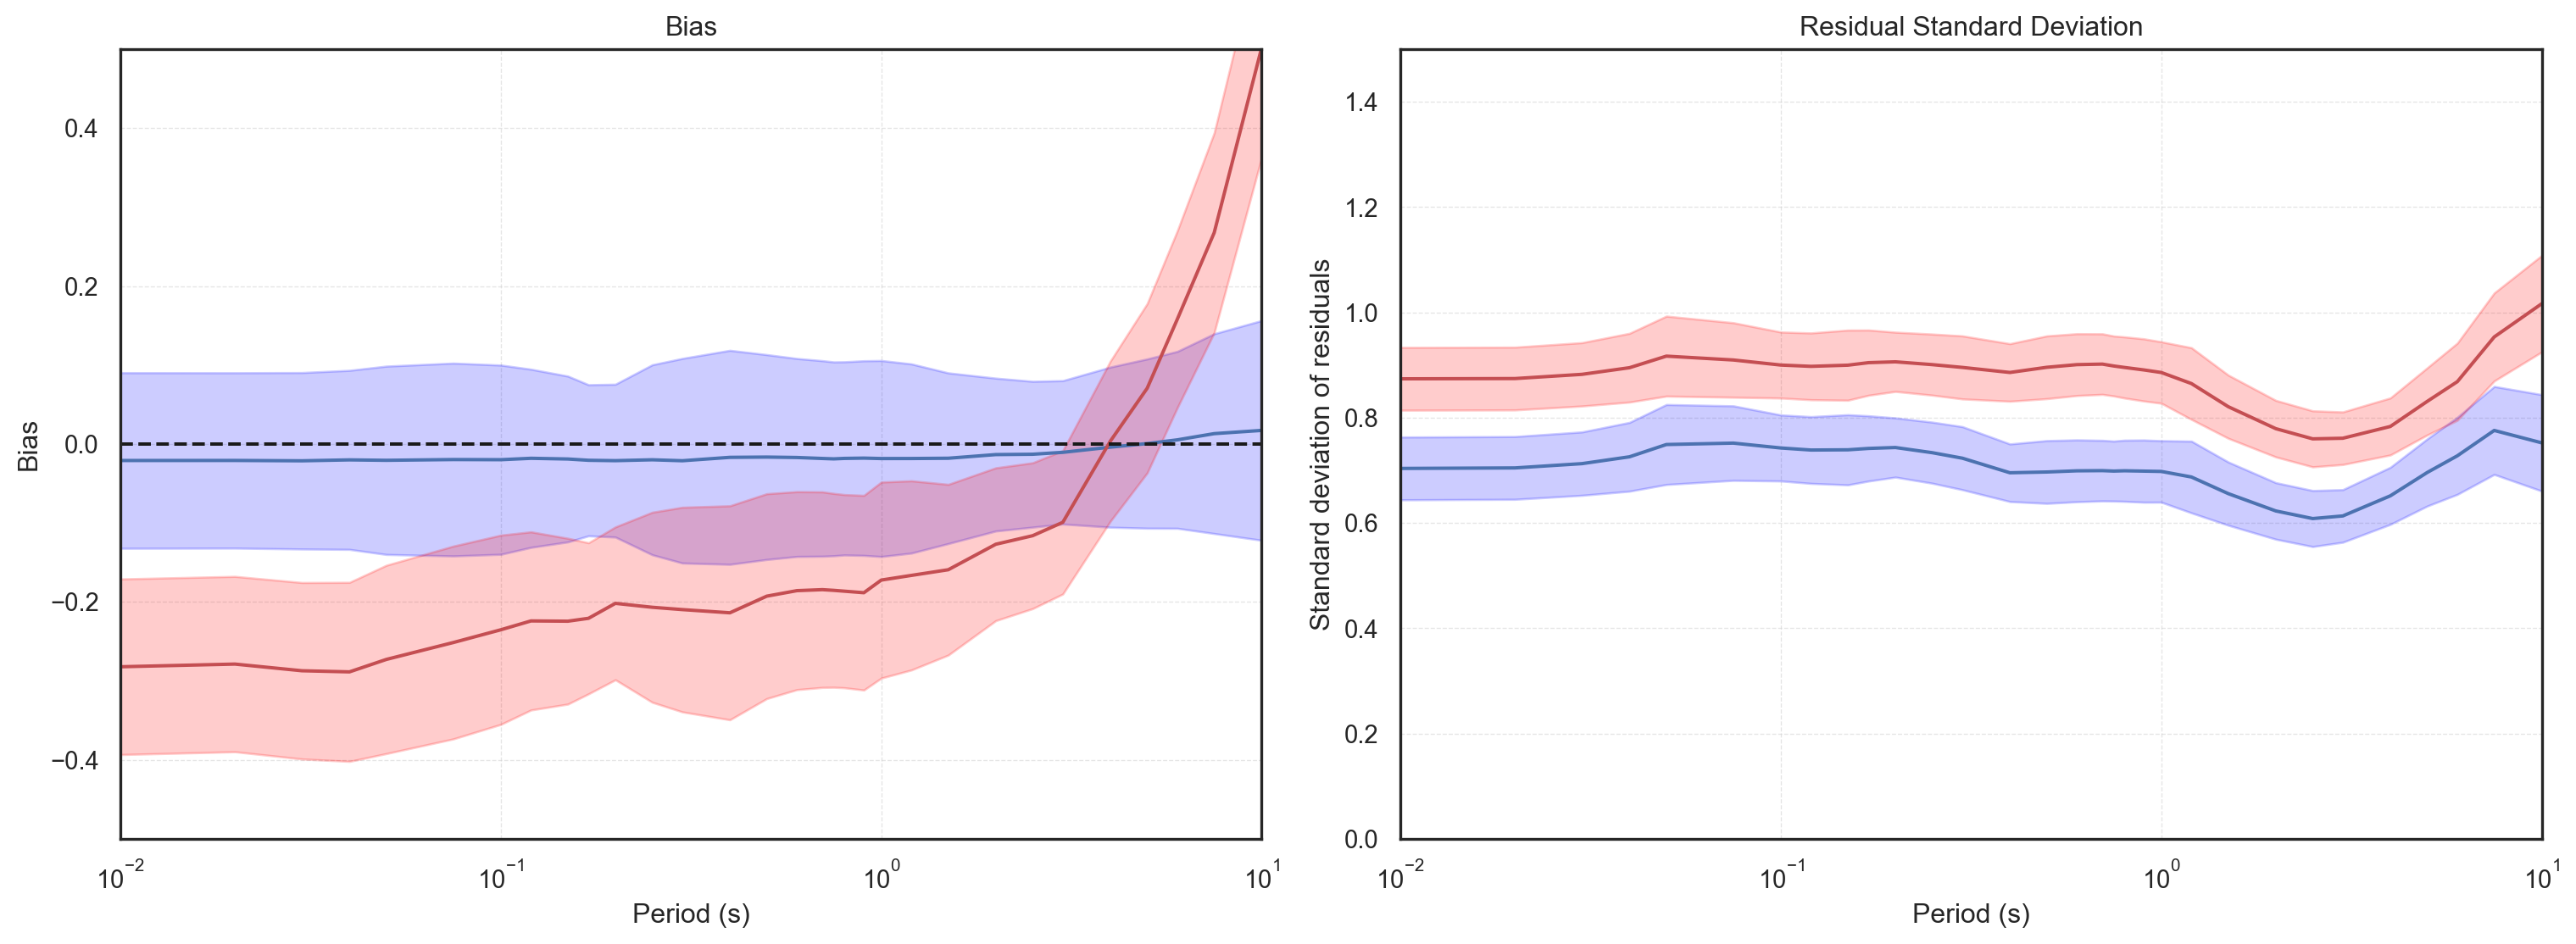

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

cv_val_res_mean_values = np.stack([cur_cv_val_res[sr.constants.PSA_KEYS].mean().values for cur_cv_val_res in gnn_cv_val_res_dfs.values()], axis=0)
cv_val_bias_std = cv_val_res_mean_values.std(axis=0)

# Individual CV biases
# ax1.semilogx(np.asarray(sr.constants.PERIODS)[:, None], cv_val_res_mean_values.T, c="gray", alpha=0.5, linestyle="--", linewidth=1.0)

### Bias
# GNN
ax1.semilogx(sr.constants.PERIODS, gnn_val_res_mean_std_df.loc[sr.constants.PSA_KEYS, "mean"], c="b")
ax1.fill_between(sr.constants.PERIODS, gnn_val_res_mean_std_df.loc[sr.constants.PSA_KEYS, "mean"] - cv_val_bias_std, gnn_val_res_mean_std_df.loc[sr.constants.PSA_KEYS, "mean"] + cv_val_bias_std, alpha=0.2, color="blue")

# cIM
ax1.semilogx(sr.constants.PERIODS, cim_val_res_mean_std_df.loc[sr.constants.PSA_KEYS, "mean"], c="r")
ax1.fill_between(sr.constants.PERIODS, cim_val_res_mean_std_df.loc[sr.constants.PSA_KEYS, "mean"] - cv_val_bias_std, cim_val_res_mean_std_df.loc[sr.constants.PSA_KEYS, "mean"] + cv_val_bias_std, alpha=0.2, color="red")

ax1.axhline(0, color="k", linestyle="--")
ax1.set_xlabel(f"Period (s)")
ax1.set_ylabel(f"Bias")
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_xlim(0.01, 10)
ax1.set_ylim(-0.5, 0.5)
ax1.set_title("Bias")

cv_val_res_std_values = np.stack([cur_cv_val_res[sr.constants.PSA_KEYS].std().values for cur_cv_val_res in gnn_cv_val_res_dfs.values()], axis=0)
cv_val_res_std_std = cv_val_res_std_values.std(axis=0)

# Individual CV residual standard deviations
# ax2.semilogx(np.asarray(sr.constants.PERIODS)[:, None], cv_val_res_std_values.T, c="gray", alpha=0.5, linestyle="--",linewidth=1.0)
        
### Residual Standard Deviation
# GNN
ax2.semilogx(sr.constants.PERIODS, gnn_val_res_mean_std_df.loc[sr.constants.PSA_KEYS, "std"], c="b")
ax2.fill_between(sr.constants.PERIODS, gnn_val_res_mean_std_df.loc[sr.constants.PSA_KEYS, "std"] - cv_val_res_std_std, gnn_val_res_mean_std_df.loc[sr.constants.PSA_KEYS, "std"] + cv_val_res_std_std, alpha=0.2, color="blue")

# cIM
ax2.semilogx(sr.constants.PERIODS, cim_val_res_mean_std_df.loc[sr.constants.PSA_KEYS, "std"], c="r")
ax2.fill_between(sr.constants.PERIODS, cim_val_res_mean_std_df.loc[sr.constants.PSA_KEYS, "std"] - cv_val_res_std_std, cim_val_res_mean_std_df.loc[sr.constants.PSA_KEYS, "std"] + cv_val_res_std_std, alpha=0.2, color="red")

ax2.set_xlabel(f"Period (s)")
ax2.set_ylabel(f"Standard deviation of residuals")
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_xlim(0.01, 10)
ax2.set_ylim(0, 1.5)
ax2.set_title("Residual Standard Deviation");

fig.tight_layout()